In [1]:
import pandas as pd

df = pd.read_csv("Housing.csv")

df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(545, 13)


In [3]:
print("Columns:")
print(df.columns)

Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [5]:
target = "price"

features = df.drop("price", axis=1).columns

print("Target Variable:", target)
print("Features:")
print(features)

Target Variable: price
Features:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='str')


In [6]:
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [7]:


df = pd.get_dummies(df, drop_first=True)

print("New Shape:", df.shape)

df.head()

New Shape: (545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [8]:
X = df.drop("price", axis=1)

y = df["price"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(436, 13)
(109, 13)


In [9]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Model Trained Successfully")

Model Trained Successfully


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, lr_pred)

rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

r2 = r2_score(y_test, lr_pred)

print("MAE =", mae)
print("RMSE =", rmse)
print("R2 Score =", r2)

MAE = 970043.4039201637
RMSE = 1324506.9600914384
R2 Score = 0.6529242642153186


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [12]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("MAE =", rf_mae)
print("RMSE =", rf_rmse)
print("R2 Score =", rf_r2)

MAE = 1021546.0353211008
RMSE = 1400565.9728553821
R2 Score = 0.611918531405699


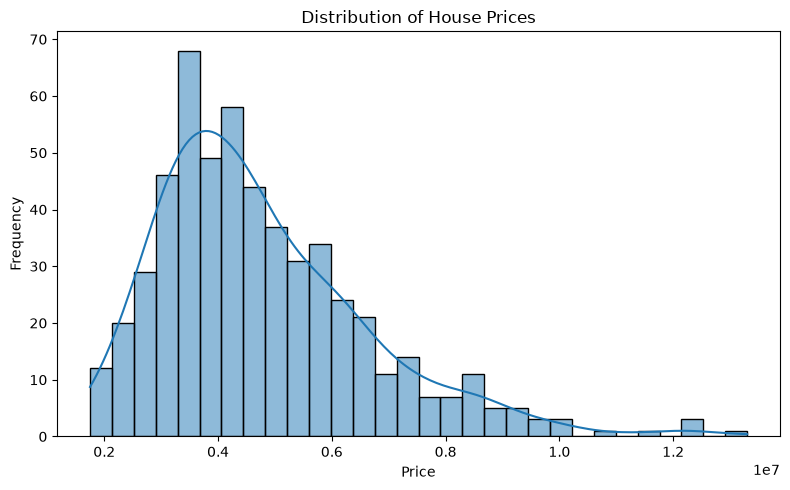

In [22]:

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("chart1_histogram.png", dpi=300)

plt.show()

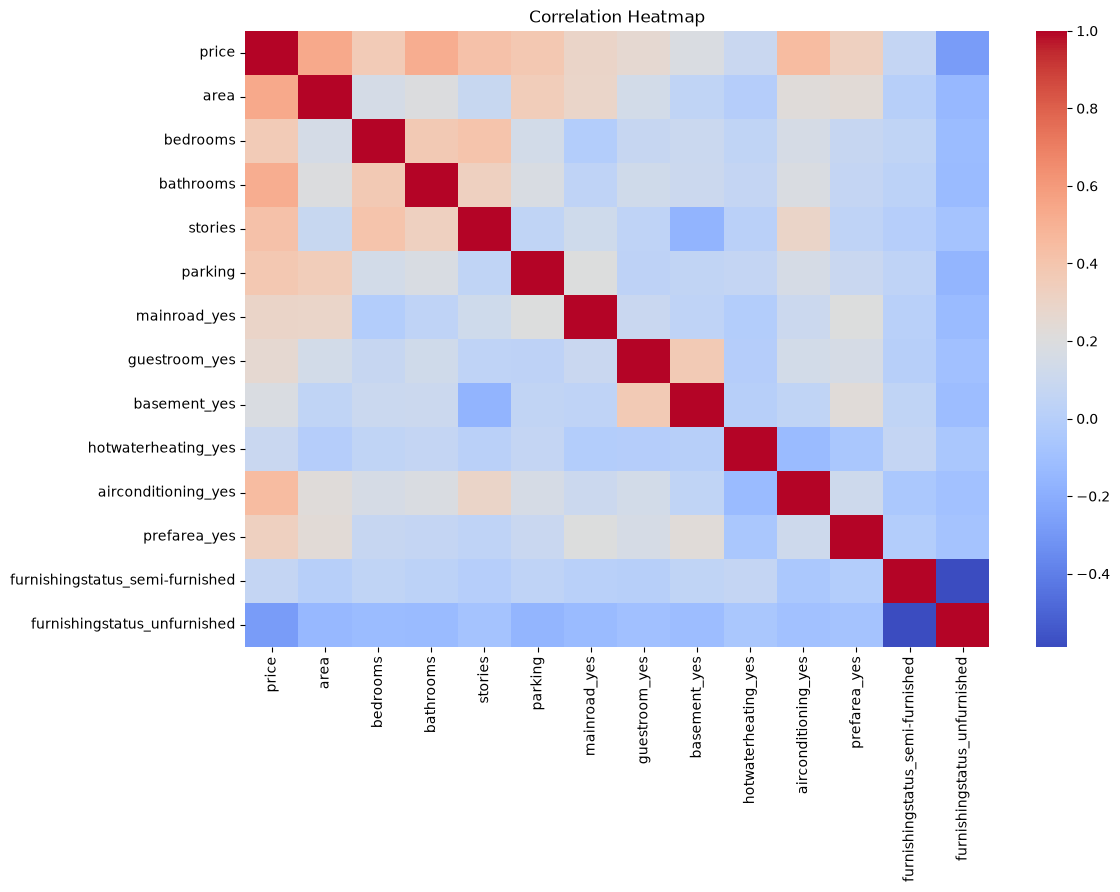

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()


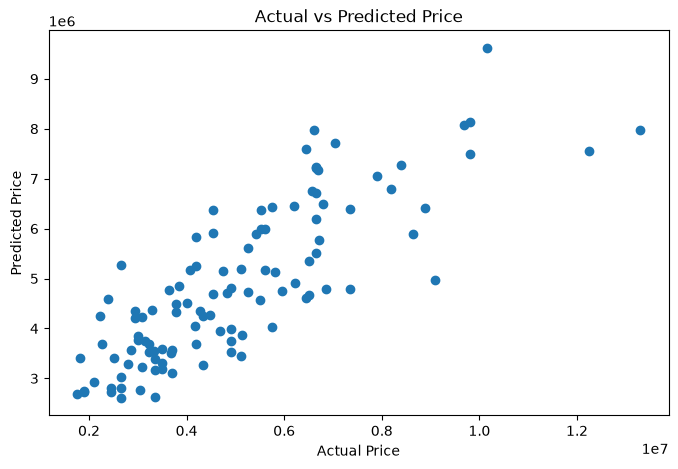

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                         Feature  Importance
0                           area    0.468430
2                      bathrooms    0.151483
9            airconditioning_yes    0.062672
4                        parking    0.057455
3                        stories    0.057133
1                       bedrooms    0.048413
12  furnishingstatus_unfurnished    0.035011
7                   basement_yes    0.030823
10                  prefarea_yes    0.030689
8            hotwaterheating_yes    0.017226


In [17]:
import os

print(os.listdir())

['Housing.csv', 'chart1_histogram.png', '.ipynb_checkpoints', 'analysis.ipynb']


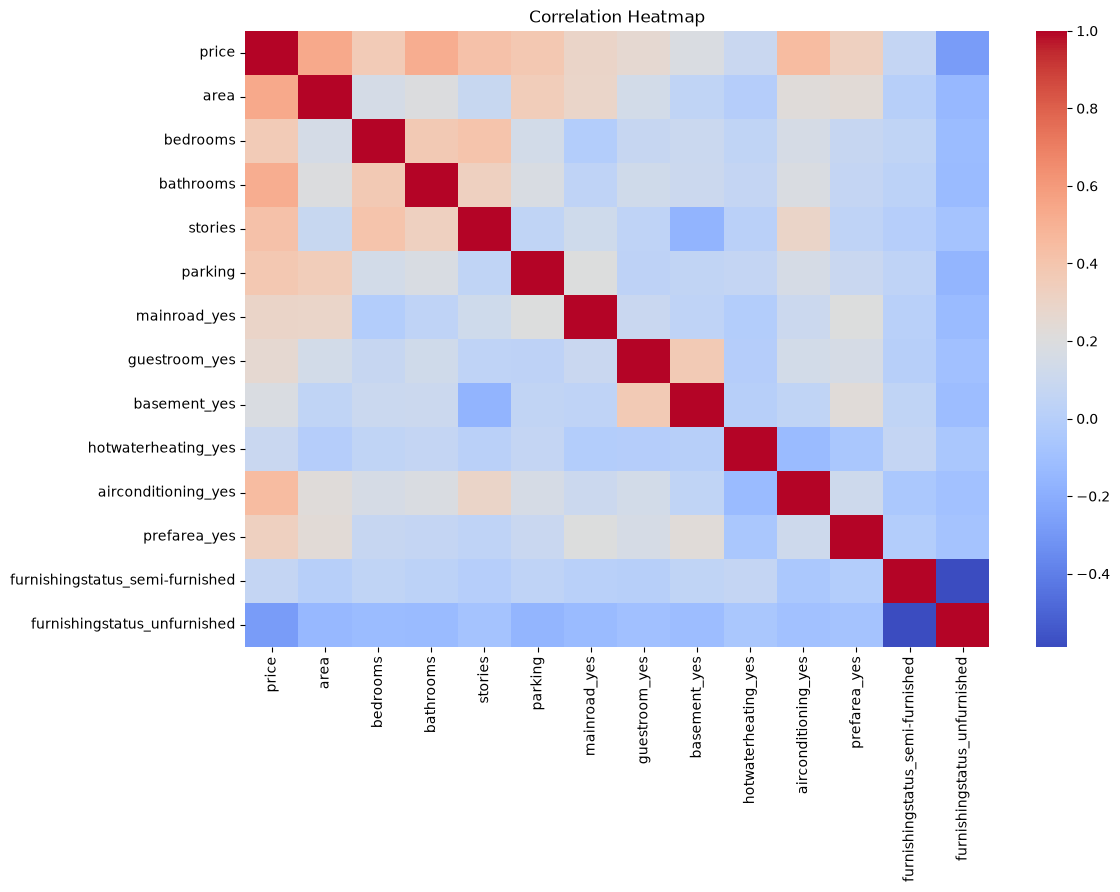

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("chart2_heatmap.png")
plt.show()

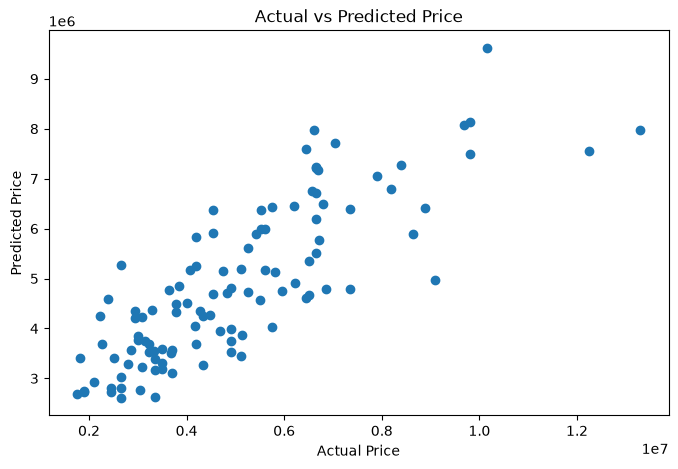

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.savefig("chart3_actual_vs_predicted.png")
plt.show()

In [20]:
import os
print(os.listdir())

['Housing.csv', 'chart3_actual_vs_predicted.png', 'chart1_histogram.png', 'chart2_heatmap.png', '.ipynb_checkpoints', 'analysis.ipynb']
